Generated at: 2026-05-31 22:31:38 MSK

# MDD latency: existing vs improved

**Задача:** проверить, что cached/precomputed вариант быстрее request-time compute.

- existing: `N(3.5, 0.4)`, n = `500000`
- improved: `N(2.0, 0.4)`, n = `500000`
- metric: `latency` (`ms-proxy`, [assumption] единица из ДЗ)
- alpha = `0.05`

---

In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats


**Пути / константы**

- notebook ищет корень `ml005/` без абсолютного пути
- все файлы пишутся в `../data`, `../reports`, `../adr`
- seed фиксируем -> прогон воспроизводимый
- TODO-stub: b01/b09 должны подтвердить, что MDD deps (`numpy` / `scipy` / `matplotlib` / `pandas`) есть в requirements; b10 requirements не редактирует

In [2]:
def find_ml005_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if candidate.name == "ml005" and (candidate / "requirements.txt").exists():
            return candidate
        nested = candidate / "ml005"
        if (nested / "requirements.txt").exists():
            return nested
    raise RuntimeError("ml005 root not found")


PROJECT_DIR = find_ml005_root()
DATA_DIR = PROJECT_DIR / "data"
REPORTS_DIR = PROJECT_DIR / "reports"
ADR_DIR = PROJECT_DIR / "adr"

for directory in (DATA_DIR, REPORTS_DIR, ADR_DIR):
    directory.mkdir(parents=True, exist_ok=True)

N_SAMPLES = 500_000
SEED = 42
EXISTING_MEAN = 3.5
IMPROVED_MEAN = 2.0
SIGMA = 0.4
ALPHA = 0.05
KDE_SAMPLES = 50_000
MS_PROXY_MULTIPLIER = 150.0  # [assumption] only for SLO sanity check, not a real prod unit
SLO_MS = 500.0


def rel(path: Path) -> str:
    return str(path.relative_to(PROJECT_DIR)).replace("\\", "/")


**Генерация данных**

- existing = request-time feature compute
- improved = cached/precomputed top-N
- сохраняем одну колонку `latency` (без timestamp / без реальных идентификаторов)

In [3]:
rng = np.random.default_rng(SEED)
existing = rng.normal(EXISTING_MEAN, SIGMA, N_SAMPLES)
improved = rng.normal(IMPROVED_MEAN, SIGMA, N_SAMPLES)

reference_path = DATA_DIR / "reference_latency.csv"
new_path = DATA_DIR / "new_latency.csv"

pd.DataFrame({"latency": existing}).to_csv(reference_path, index=False)
pd.DataFrame({"latency": improved}).to_csv(new_path, index=False)

print(f"saved {rel(reference_path)} rows={len(existing)}")
print(f"saved {rel(new_path)} rows={len(improved)}")


saved data/reference_latency.csv rows=500000
saved data/new_latency.csv rows=500000


**Описательная статистика**

- смотрю mean / median / p95 / p99
- [assumption] для связи с SLO считаю `1 ms-proxy = 150 ms`
- это только ДЗ-интерпретация: сам SLO берем из master TZ как `p95 /score < 500 ms (cached)`

In [4]:
def describe_latency(values: np.ndarray) -> dict[str, float]:
    return {
        "mean": float(np.mean(values)),
        "median": float(np.median(values)),
        "p95": float(np.percentile(values, 95)),
        "p99": float(np.percentile(values, 99)),
    }


stats_table = pd.DataFrame(
    [describe_latency(existing), describe_latency(improved)],
    index=["existing", "improved"],
)
stats_table["p95_ms_assumption"] = stats_table["p95"] * MS_PROXY_MULTIPLIER
stats_table["slo_500ms_status"] = np.where(
    stats_table["p95_ms_assumption"] < SLO_MS,
    "pass",
    "fail",
)
stats_table


,mean,median,p95,p99,p95_ms_assumption,slo_500ms_status
existing,3.499797,3.499340,4.157986,4.432341,623.697895,fail
improved,2.000281,2.000117,2.658702,2.929972,398.805259,pass


**Гипотезы**

- H0: `mean_improved >= mean_existing` (improved не быстрее)
- H1: `mean_improved < mean_existing` (improved быстрее)
- порядок аргументов важен: `test(improved, existing, alternative="less")`
- `less` значит improved latency меньше existing latency

In [5]:
welch_result = stats.ttest_ind(
    improved,
    existing,
    equal_var=False,
    alternative="less",
)
mannwhitney_result = stats.mannwhitneyu(
    improved,
    existing,
    alternative="less",
)

decision_reject_h0 = bool(welch_result.pvalue < ALPHA)

test_summary = pd.DataFrame(
    [
        {
            "test": "Welch t-test",
            "alternative": "less",
            "statistic": float(welch_result.statistic),
            "p_value": float(welch_result.pvalue),
            "decision": "H0 rejected" if decision_reject_h0 else "H0 not rejected",
        },
        {
            "test": "Mann-Whitney U",
            "alternative": "less",
            "statistic": float(mannwhitney_result.statistic),
            "p_value": float(mannwhitney_result.pvalue),
            "decision": "H0 rejected" if mannwhitney_result.pvalue < ALPHA else "H0 not rejected",
        },
    ]
)
test_summary


,test,alternative,statistic,p_value,decision
0,Welch t-test,less,-1.873490e+03,0.0,H0 rejected
1,Mann-Whitney U,less,1.001122e+09,0.0,H0 rejected


**KDE-плот**

- тесты и статистика считаются на full n = `500000`
- KDE строю на сабсэмпле `50000` только для скорости отрисовки
- линии mean добавлены как ориентир

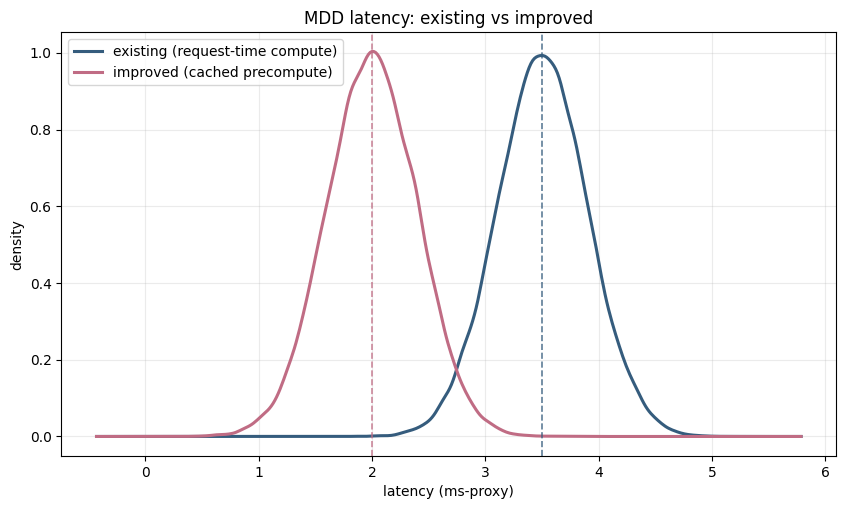

saved reports/mdd_latency_distribution.png


In [6]:
plot_rng = np.random.default_rng(SEED + 1)
existing_plot = plot_rng.choice(existing, size=KDE_SAMPLES, replace=False)
improved_plot = plot_rng.choice(improved, size=KDE_SAMPLES, replace=False)

x_min = min(existing_plot.min(), improved_plot.min()) - 0.5
x_max = max(existing_plot.max(), improved_plot.max()) + 0.5
x_grid = np.linspace(x_min, x_max, 400)

existing_kde = stats.gaussian_kde(existing_plot)
improved_kde = stats.gaussian_kde(improved_plot)

plt.figure(figsize=(10, 5.5))
plt.plot(
    x_grid,
    existing_kde(x_grid),
    label="existing (request-time compute)",
    color="#355C7D",
    linewidth=2.2,
)
plt.plot(
    x_grid,
    improved_kde(x_grid),
    label="improved (cached precompute)",
    color="#C06C84",
    linewidth=2.2,
)
plt.axvline(existing.mean(), color="#355C7D", linestyle="--", linewidth=1.2, alpha=0.8)
plt.axvline(improved.mean(), color="#C06C84", linestyle="--", linewidth=1.2, alpha=0.8)
plt.title("MDD latency: existing vs improved")
plt.xlabel("latency (ms-proxy)")
plt.ylabel("density")
plt.legend()
plt.grid(alpha=0.25)

plot_path = REPORTS_DIR / "mdd_latency_distribution.png"
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()

print(f"saved {rel(plot_path)}")


**Запись report + ADR**

- report = короткий MDD result
- ADR = архитектурное решение для request path
- timestamp берется из runtime окружения

In [7]:
def generated_at() -> str:
    return datetime.now().astimezone().strftime("%Y-%m-%d %H:%M:%S %Z")


def fmt_float(value: float, digits: int = 6) -> str:
    return f"{value:.{digits}f}"


def fmt_stat(value: float) -> str:
    if abs(value) >= 1_000_000:
        return f"{value:.4e}".replace("e+0", "e").replace("e+", "e").replace("e-0", "e-")
    return f"{value:.3f}"


def fmt_pvalue(value: float) -> str:
    return "0.00000000" if value < 1e-8 else f"{value:.8f}"


ts = generated_at()
existing_stats = describe_latency(existing)
improved_stats = describe_latency(improved)
welch_p = fmt_pvalue(float(welch_result.pvalue))
mw_p = fmt_pvalue(float(mannwhitney_result.pvalue))
architecture_decision = "move heavy feature compute to batch + serve precomputed top-N from cache"

report_path = REPORTS_DIR / "mdd_test_result.md"
report_text = f"""Generated at: {ts}

# MDD latency test

- metric: `latency` (ms-proxy)
- n existing / n improved: `{N_SAMPLES}` / `{N_SAMPLES}`
- seed: `{SEED}`
- existing mean / median: `{fmt_float(existing_stats['mean'])}` / `{fmt_float(existing_stats['median'])}`
- improved mean / median: `{fmt_float(improved_stats['mean'])}` / `{fmt_float(improved_stats['median'])}`
- existing p95 / p99: `{fmt_float(existing_stats['p95'])}` / `{fmt_float(existing_stats['p99'])}`
- improved p95 / p99: `{fmt_float(improved_stats['p95'])}` / `{fmt_float(improved_stats['p99'])}`
- [assumption] SLO sanity: `1 ms-proxy = {MS_PROXY_MULTIPLIER:.0f} ms`, improved p95 `{improved_stats['p95'] * MS_PROXY_MULTIPLIER:.2f} ms` -> pass `< 500 ms`, existing p95 `{existing_stats['p95'] * MS_PROXY_MULTIPLIER:.2f} ms` -> fail
- H0: `mean_improved >= mean_existing`
- H1: `mean_improved < mean_existing`
- test: `Welch t-test`, alternative=`less`
- alpha: `{ALPHA}`
- statistic: `{float(welch_result.statistic):.3f}`
- p_value: `{welch_p}`
- robustness test: `Mann-Whitney U`, alternative=`less`
- robustness statistic: `{fmt_stat(float(mannwhitney_result.statistic))}`
- robustness p_value: `{mw_p}`
- decision: `{architecture_decision}`
- TODO-stub: `b01/b09` должны подтвердить MDD deps (`numpy` / `scipy` / `matplotlib` / `pandas`) в requirements; b10 requirements не редактирует

**Вывод:** p-value ниже alpha -> improved быстрее статистически значимо, решение принято.
"""
report_path.write_text(report_text, encoding="utf-8")

adr_path = ADR_DIR / "0001-latency-mdd-decision.md"
adr_text = f"""Generated at: {ts}

# ADR 0001: latency MDD decision for cached NBO scoring

## Status

Accepted

## Context

Есть два синтетических набора latency для NBO scoring service:

- `data/reference_latency.csv` - existing path, request-time feature compute, n = `{N_SAMPLES}`
- `data/new_latency.csv` - improved path, cached precomputed top-N, n = `{N_SAMPLES}`

Метрика системная: latency сервиса `/score`, не accuracy модели. Existing-распределение около `{EXISTING_MEAN}`, т.к. тяжелые фичи считаются в request path. Improved-распределение около `{IMPROVED_MEAN}`, т.к. API отдает предрасчитанный top-N из feature store/cache.

[assumption] единица latency = ms-proxy из ДЗ. Для SLO sanity в notebook использован множитель `{MS_PROXY_MULTIPLIER:.0f} ms` на 1 proxy-unit: improved p95 проходит `< 500 ms`, existing p95 не проходит.

## Decision

- H0: `mean_improved >= mean_existing` (improved не быстрее)
- H1: `mean_improved < mean_existing` (improved быстрее)
- chosen test: `Welch t-test`, alternative=`less`, порядок аргументов `ttest_ind(improved, existing, equal_var=False, alternative="less")`
- alpha: `{ALPHA}`
- p-value: `{welch_p}`
- robustness test: `Mann-Whitney U`, alternative=`less`, p-value `{mw_p}`
- decision rule: `p_value < alpha` -> H0 rejected, H1 accepted
- final architecture decision: перенести тяжелый feature-compute в batch preprocessing + feature store/cache; API `/score` отдает предрасчитанный top-N из кэша; держать p95 `/score` latency SLO `< 500 ms` (master TZ, section 6)

## Consequences

Плюсы:

- ниже p95/p99 latency
- предсказуемый SLA для scoring request path
- inference из кэша без live remote sync в request path

Минусы:

- freshness lag: кэш может стареть между batch refresh
- нужен DAG/data-freshness monitoring для batch features
- остается cache invalidation

Что мониторим дальше:

- p95/p99 latency `/score`
- долю stale cache
- data-freshness в DAG
"""
adr_path.write_text(adr_text, encoding="utf-8")

print(f"saved {rel(report_path)}")
print(f"saved {rel(adr_path)}")


saved reports/mdd_test_result.md
saved adr/0001-latency-mdd-decision.md


**Вывод:**

- Welch t-test + Mann-Whitney U дают p-value ниже alpha
- H0 rejected -> improved быстрее
- архитектурно: heavy feature compute уходит в batch, `/score` читает top-N из cache

In [8]:
produced = [
    reference_path,
    new_path,
    plot_path,
    report_path,
    adr_path,
]

print(f"welch_p_value={float(welch_result.pvalue):.12g}")
print(f"mannwhitney_p_value={float(mannwhitney_result.pvalue):.12g}")
print("decision=H0 rejected -> move heavy feature compute to batch + cache")
print("artifacts:")
for artifact in produced:
    print(f"- {rel(artifact)}")


welch_p_value=0
mannwhitney_p_value=0
decision=H0 rejected -> move heavy feature compute to batch + cache
artifacts:
- data/reference_latency.csv
- data/new_latency.csv
- reports/mdd_latency_distribution.png
- reports/mdd_test_result.md
- adr/0001-latency-mdd-decision.md
